In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
assignment = pd.read_csv('Assignment-2_Data.csv')

In [18]:
assignment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         45211 non-null  int64  
 1   age        45202 non-null  float64
 2   job        45211 non-null  object 
 3   marital    45211 non-null  object 
 4   education  45211 non-null  object 
 5   default    45211 non-null  object 
 6   balance    45208 non-null  float64
 7   housing    45211 non-null  object 
 8   loan       45211 non-null  object 
 9   contact    45211 non-null  object 
 10  day        45211 non-null  int64  
 11  month      45211 non-null  object 
 12  duration   45211 non-null  int64  
 13  campaign   45211 non-null  int64  
 14  pdays      45211 non-null  int64  
 15  previous   45211 non-null  int64  
 16  poutcome   45211 non-null  object 
 17  y          45211 non-null  object 
dtypes: float64(2), int64(6), object(10)
memory usage: 6.2+ MB


## **EDA**

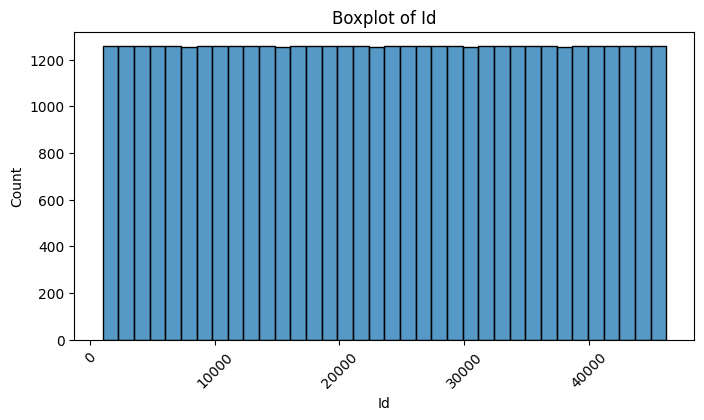

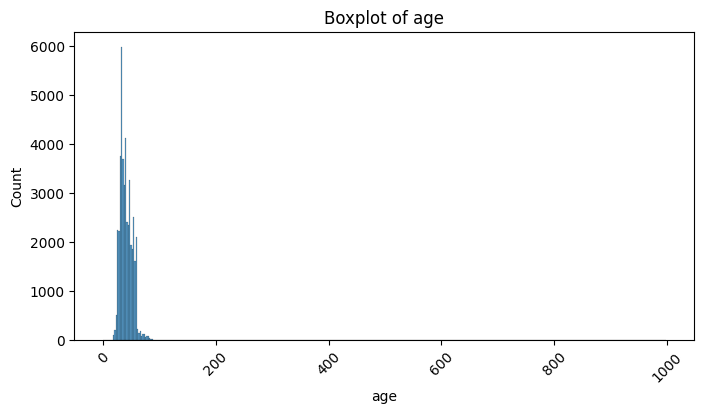

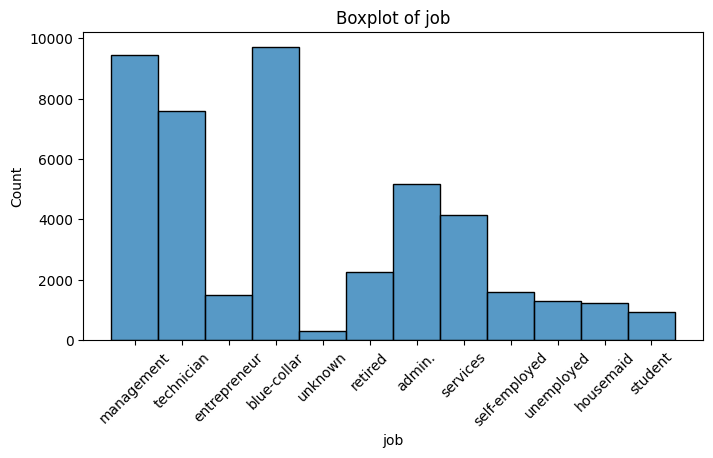

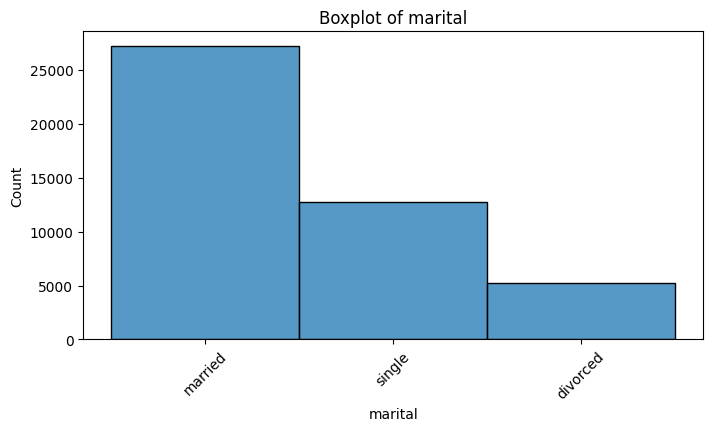

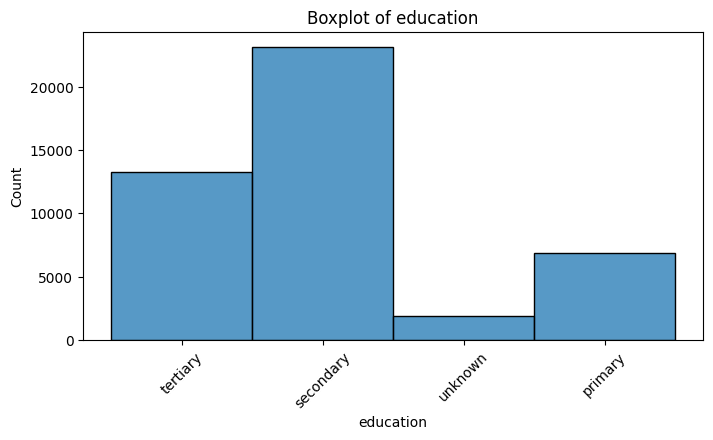

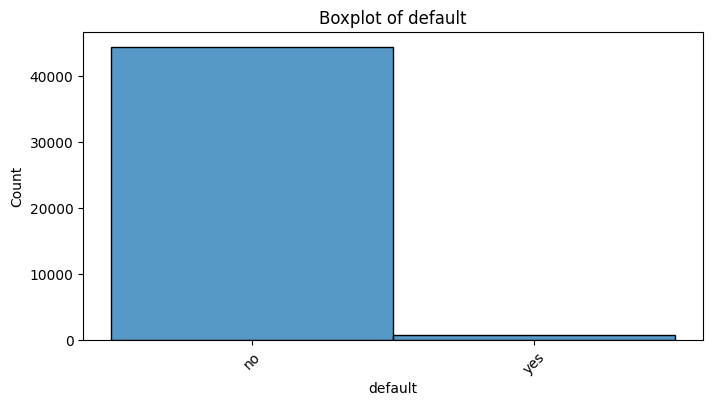

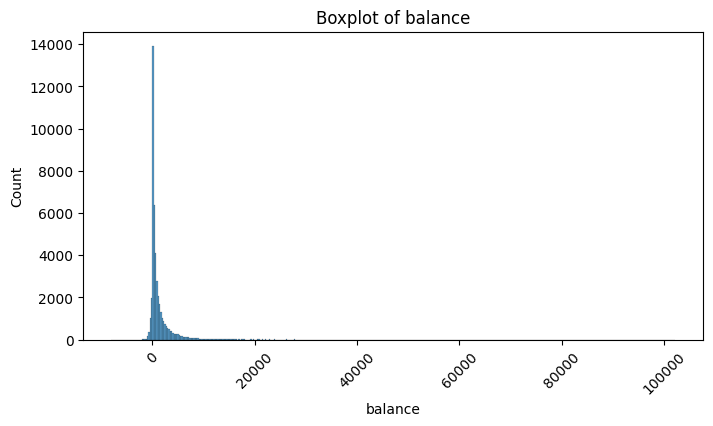

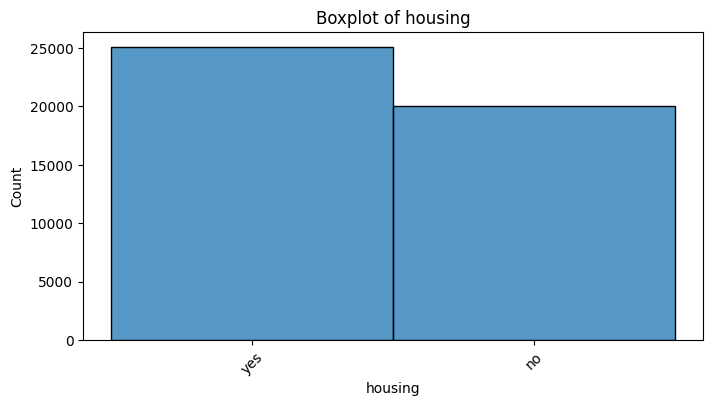

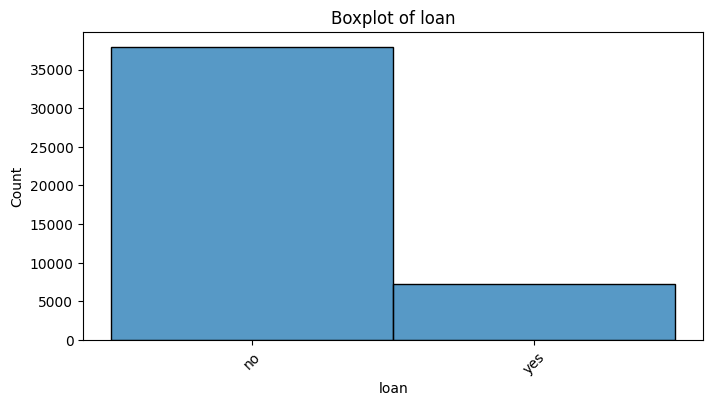

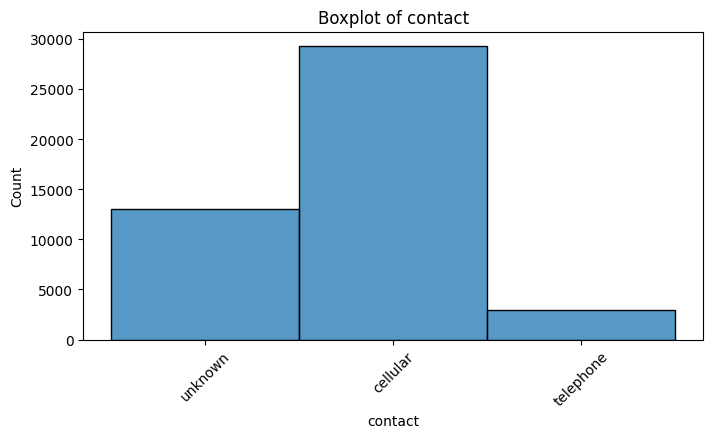

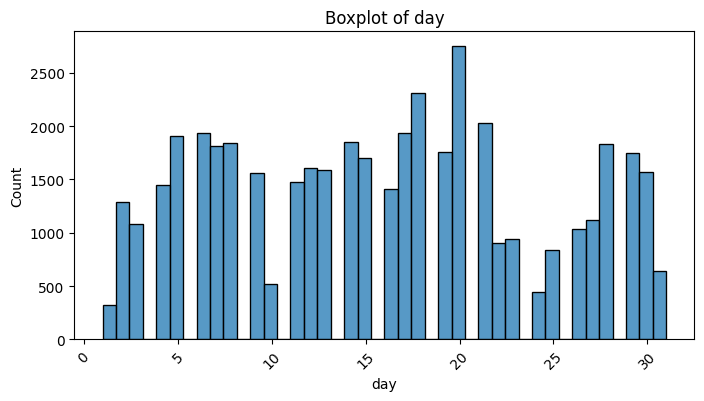

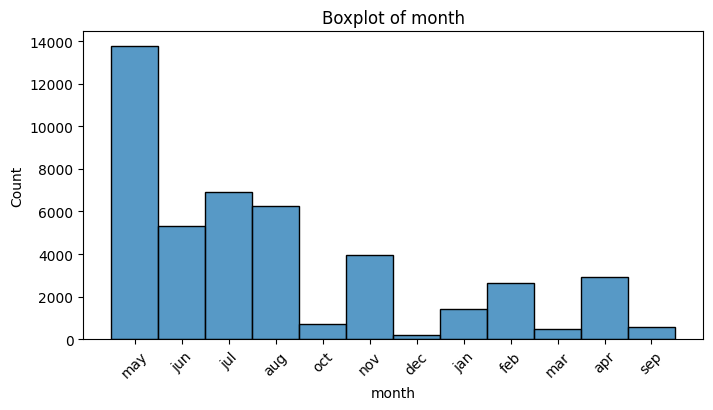

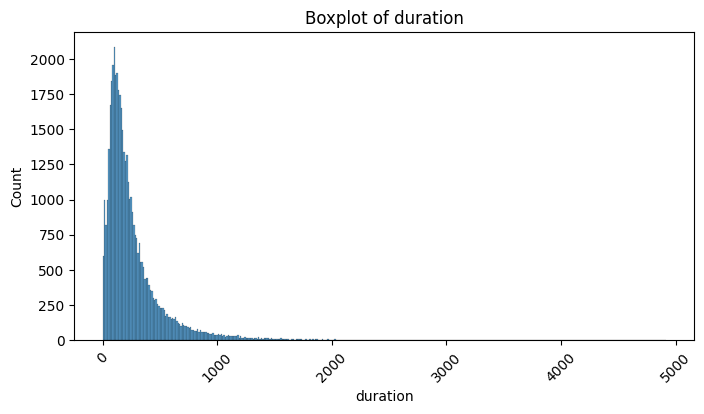

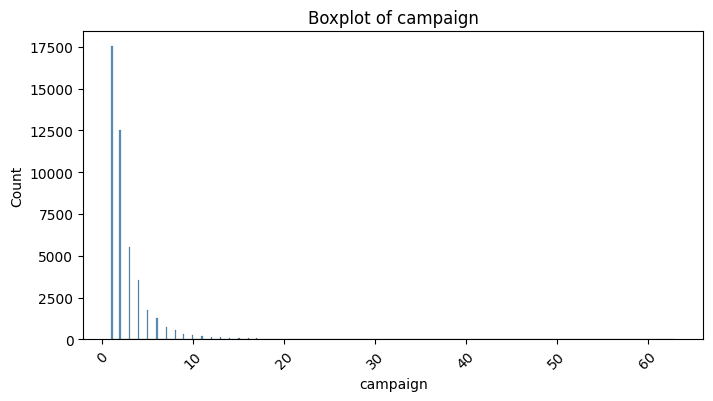

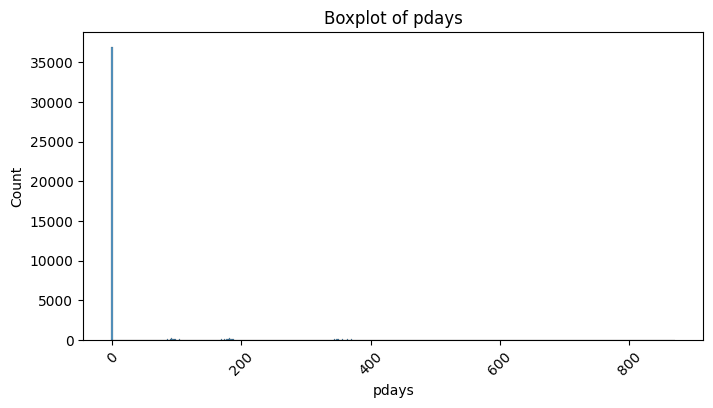

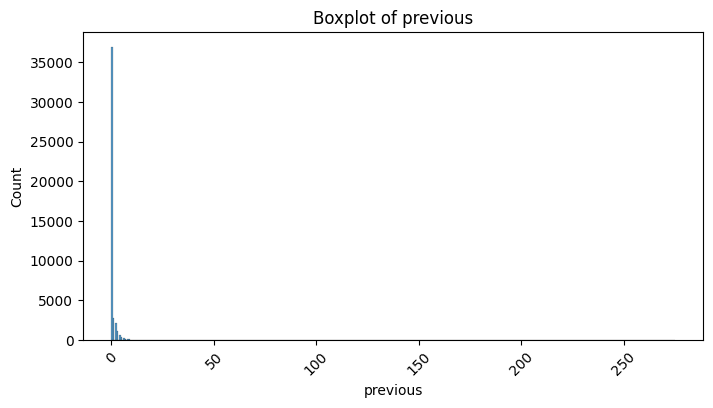

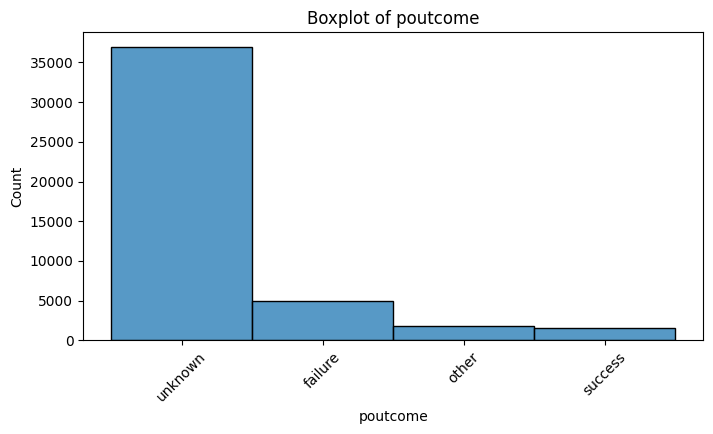

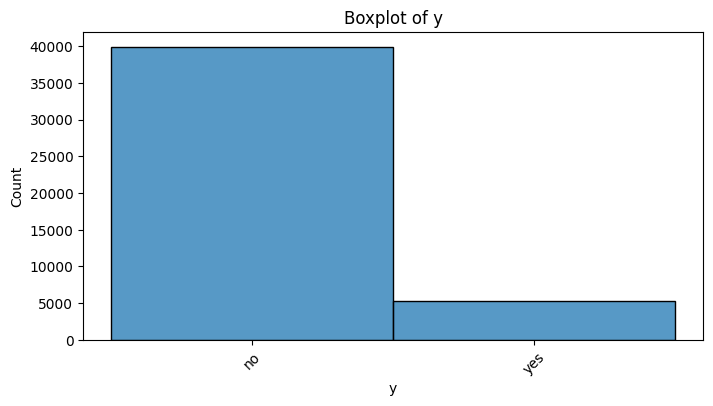

In [19]:
# boxplot per colom

for column in assignment.columns:
    plt.figure(figsize=(8, 4))
    plt.xticks(rotation=45)
    sns.histplot(x=assignment[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

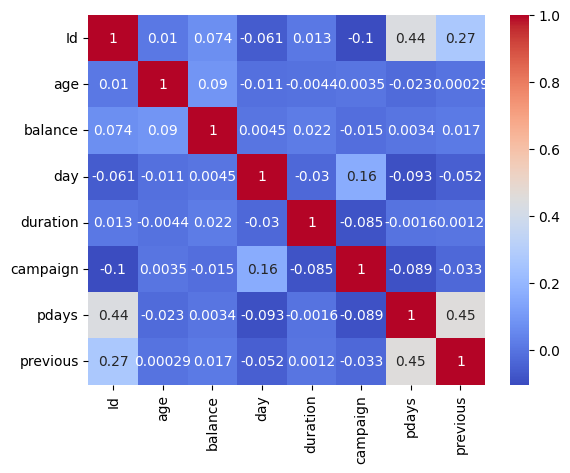

In [20]:
sns.heatmap(assignment.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.show()

## **MODEL**

In [21]:
assignment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         45211 non-null  int64  
 1   age        45202 non-null  float64
 2   job        45211 non-null  object 
 3   marital    45211 non-null  object 
 4   education  45211 non-null  object 
 5   default    45211 non-null  object 
 6   balance    45208 non-null  float64
 7   housing    45211 non-null  object 
 8   loan       45211 non-null  object 
 9   contact    45211 non-null  object 
 10  day        45211 non-null  int64  
 11  month      45211 non-null  object 
 12  duration   45211 non-null  int64  
 13  campaign   45211 non-null  int64  
 14  pdays      45211 non-null  int64  
 15  previous   45211 non-null  int64  
 16  poutcome   45211 non-null  object 
 17  y          45211 non-null  object 
dtypes: float64(2), int64(6), object(10)
memory usage: 6.2+ MB


In [ ]:
assignment.columns

Index(['Id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
X_before = assignment['']
y = assignment['']

In [ ]:
# normalisasi (X - X.min) / (X.max - X.min)
X = (X_before - X_before.min()) / (X_before.max() - X_before.min())

# standarisasi (X - X.mean) / X - X.std
X =(X_before - X_before.mean()) / X_before - X_before.std()

In [ ]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(len(idx_0) * 0.8)
train_1 = int(len(idx_1) * 0.8)

train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train = X.iloc[train_idx].values
y_train = y.iloc[train_idx].values
X_test = X.iloc[test_idx].values
y_test = y.iloc[test_idx].values

In [ ]:
def knn(X_train, y_train, X_test, k=3, p=2, weight='uniform'):
    # distance using minkowski
    distance = np.zeros((X_test.shape[0], X_train.shape[0]))
    for i in range(X_test.shape[0]):
        distance[i] = np.sum(np.abs(X_train - X_test[i])**p, axis=1)**(1/p)

    sort = np.argsort(distance)
    nearest = sort[:k]
    nearest_label = y_train[nearest]
    nearest_distance = distance[nearest]

    if weight == 'uniform':
        votes = np.bincount(nearest_label)
    elif weight == 'weighted':
        weights = 1 / (nearest_distance + 1e-5)
        votes = np.zeros(np.max(y_train) + 1)
        for i in range(len(nearest_label)):
            votes[nearest_label[i]] += weights[i]

    return votes

In [ ]:
# mencari weight terbaik

vote_method =['uniform', 'weighted']
best_weight = {}

for method in vote_method:
    correct = 0
    for i in range(len(X_test)):
        pred = knn(X_train, y_train, X_test[i], k=5, p=2, weight=method)
        predicted_label = np.argmax(pred)
        if predicted_label == y_test[i]:
            correct += 1
    acc = correct / len(X_test)
    best_weight[method] = acc
    print(f'method {method}, acc: {acc:.4f}')

In [ ]:
# tune k terbaik

k_range = [3,5,7,9,11,13,15,17,19,21]
best_k = {}

for k in k_range:
    correct = 0
    for i in range(len(X_test)):
        pred = knn(X_train, y_train, X_test[i], k=k, p=2, weight='uniform')
        predicted_label = np.argmax(pred)
        if predicted_label == y_test[i]:
            correct += 1
    acc = correct / len(X_test)
    best_k[k] = acc
    print(f'k: {k}, acc: {acc:.4f}')

## **EVALUASI**

In [ ]:
def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1_score

In [ ]:
pred_eulidean = knn(X_train, y_train, X_test, k=best_k, p=2, weight='uniform')
pred_manhattan = knn(X_train, y_train, X_test, k=best_k, p=1, weight='uniform')
pred_chebyshev = knn(X_train, y_train, X_test, k=best_k, p=np.inf, weight='uniform')

# Prediksi Train
y_train_pred_eulidean = np.argmax(knn(X_train, y_train, X_train, k=best_k, p=2, weight='uniform'), axis=1)
y_train_pred_manhattan = np.argmax(knn(X_train, y_train, X_train, k=best_k, p=1, weight='uniform'), axis=1)
y_train_pred_chebyshev = np.argmax(knn(X_train, y_train, X_train, k=best_k, p=np.inf, weight='uniform'), axis=1)

acc_train_eu, precision_train_eu, recall_train_eu, f1_train_eu = evaluate(y_train, y_train_pred_eulidean)
acc_train_ma, precision_train_ma, recall_train_ma, f1_train_ma = evaluate(y_train, y_train_pred_manhattan)
acc_train_ch, precision_train_ch, recall_train_ch, f1_train_ch = evaluate(y_train, y_train_pred_chebyshev)

# Prediksi Tes

y_pred_eulidean = np.argmax(pred_eulidean, axis=1)
y_pred_manhattan = np.argmax(pred_manhattan, axis=1)
y_pred_chebyshev = np.argmax(pred_chebyshev, axis=1)

accuracy_eu, precision_eu, recall_eu, f1_eu = evaluate(y_test, y_pred_eulidean)
accuracy_ma, precision_ma, recall_ma, f1_ma = evaluate(y_test, y_pred_manhattan)
accuracy_ch, precision_ch, recall_ch, f1_ch = evaluate(y_test, y_pred_chebyshev)

print('Prediksi Train')
print(f'Euclidean - Accuracy: {acc_train_eu:.4f}, Precision: {precision_train_eu:.4f}, Recall: {recall_train_eu:.4f}, F1 Score: {f1_train_eu:.4f}')
print(f'Manhattan - Accuracy: {acc_train_ma:.4f}, Precision: {precision_train_ma:.4f}, Recall: {recall_train_ma:.4f}, F1 Score: {f1_train_ma:.4f}')
print(f'Chebyshev - Accuracy: {acc_train_ch:.4f}, Precision: {precision_train_ch:.4f}, Recall: {recall_train_ch:.4f}, F1 Score: {f1_train_ch:.4f}')

print('\nPrediksi Test')
print(f'Euclidean - Accuracy: {accuracy_eu:.4f}, Precision: {precision_eu:.4f}, Recall: {recall_eu:.4f}, F1 Score: {f1_eu:.4f}')
print(f'Manhattan - Accuracy: {accuracy_ma:.4f}, Precision: {precision_ma:.4f}, Recall: {recall_ma:.4f}, F1 Score: {f1_ma:.4f}')
print(f'Chebyshev - Accuracy: {accuracy_ch:.4f}, Precision: {precision_ch:.4f}, Recall: {recall_ch:.4f}, F1 Score: {f1_ch:.4f}')